In [24]:
# =========================================================
# Project: Wine Quality Prediction
# File: Red Wine EDA.ipynb
# Purpose: Exploratory Data Analysis
# Author: Mayank Kumar Dixit
# Created: 2026-02-12
# =========================================================


In [25]:
#Imports and Global Configuration

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

In [27]:
#Plot Configuration - Standardizing visuals

plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.figsize"] = (8, 5)
sns.set_style("whitegrid")


In [34]:
# Path and project constants

BASE_DIR = Path("D:/Learning/Learning")
DATA_DIR = BASE_DIR / "EDA"

#File
RAW_DATA_FILE = DATA_DIR / "winequality-red.csv"

#Reproducability
RANDOM_STATE = 42

In [35]:
#Data Loading Function

def load_data(path: Path) -> pd.DataFrame:
    """
    Load raw dataset with basic validation.
    """

    # 1. Check file existence
    if not path.exists():
        raise FileNotFoundError(f"File not found: {path}")

    # 2. Load
    df = pd.read_csv(path, sep=";")

    # 3. Sanity checks
    if df.empty:
        raise ValueError("Loaded dataset is empty")

    if df.shape[0] < 1000:
        raise ValueError("Unexpectedly small dataset")

    if df.shape[1] != 12:
        raise ValueError("Unexpected number of columns")

    return df


In [36]:
#Load the dataset

df = load_data(RAW_DATA_FILE)
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [38]:
#Schema Definition - can come from domain knowledge, inference, dataset documentation or data contracts

EXPECTED_SCHEMA = {
    "fixed acidity": "float",
    "volatile acidity": "float",
    "citric acid": "float",
    "residual sugar": "float",
    "chlorides": "float",
    "free sulfur dioxide": "float",
    "total sulfur dioxide": "float",
    "density": "float",
    "pH": "float",
    "sulphates": "float",
    "alcohol": "float",
    "quality": "int"
}

In [39]:
#Validate Schema

def validate_schema(df: pd.DataFrame, schema: dict):
    """
    Validate column presence and datatypes.
    """

    for col, expected in schema.items():

        # Check existence
        if col not in df.columns:
            raise ValueError(f"Missing column: {col}")

        actual = df[col].dtype

        # Type enforcement
        if expected == "float":
            if not np.issubdtype(actual, np.floating):
                raise TypeError(f"{col} must be float")

        if expected == "int":
            if not np.issubdtype(actual, np.integer):
                raise TypeError(f"{col} must be int")


In [41]:
validate_schema(df, EXPECTED_SCHEMA)
#Schema is validated

In [ ]:
# Data Quality Audit
# Missing values
def missing_report(df: pd.DataFrame) -> pd.Series:
    print("Below are number of missing data per column:")
    return df.isnull().sum()

In [47]:
missing_report(df)

Below are number of missing data per column:


fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [48]:
#Duplicates

def duplicate_report(df:pd.DataFrame) -> int:
    return df.duplicated().sum()

In [49]:
duplicate_report(df)

np.int64(240)

In [50]:
#Descriptive Stats
df.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1599.0,8.319637,1.741096,4.60000,7.1000,7.90000,9.200000,15.90000
volatile acidity,1599.0,0.527821,0.179060,0.12000,0.3900,0.52000,0.640000,1.58000
citric acid,1599.0,0.270976,0.194801,0.00000,0.0900,0.26000,0.420000,1.00000
residual sugar,1599.0,2.538806,1.409928,0.90000,1.9000,2.20000,2.600000,15.50000
chlorides,1599.0,0.087467,0.047065,0.01200,0.0700,0.07900,0.090000,0.61100
free sulfur dioxide,1599.0,15.874922,10.460157,1.00000,7.0000,14.00000,21.000000,72.00000
total sulfur dioxide,1599.0,46.467792,32.895324,6.00000,22.0000,38.00000,62.000000,289.00000
density,1599.0,0.996747,0.001887,0.99007,0.9956,0.99675,0.997835,1.00369
pH,1599.0,3.311113,0.154386,2.74000,3.2100,3.31000,3.400000,4.01000
sulphates,1599.0,0.658149,0.169507,0.33000,0.5500,0.62000,0.730000,2.00000


__Data Integrity Summary:__

- Rows: 1599
- Columns: 12
- Missing values: 0
- Duplicates: 240
- Schema: Valid
- Ranges: Plausible
- Overall risk: _Low_

In [53]:
# Histogram Function - plotting feature distributions

def plot_distributions(df: pd.DataFrame, bins: int = 30):
    """
    Plot feature distributions.
    """

    cols = df.columns #list of columns
    n_cols = 3 # 3 plots per row
    n_rows = (len(cols) + n_cols - 1) // n_cols # 12 slots = 4 rows * 3 columns - for viz

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(18, 5 * n_rows)
    ) # this creates a grid with fig = entire figure and axes = array of subplot objects

    axes = axes.flatten() #flatten 2D array in 1D array for proper indexing

    for i, col in enumerate(cols):
        axes[i].hist(df[col], bins=bins, edgecolor="black")
        axes[i].set_title(col)
        axes[i].set_xlabel(col)
        axes[i].set_ylabel("Count")

    # Remove empty plots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()


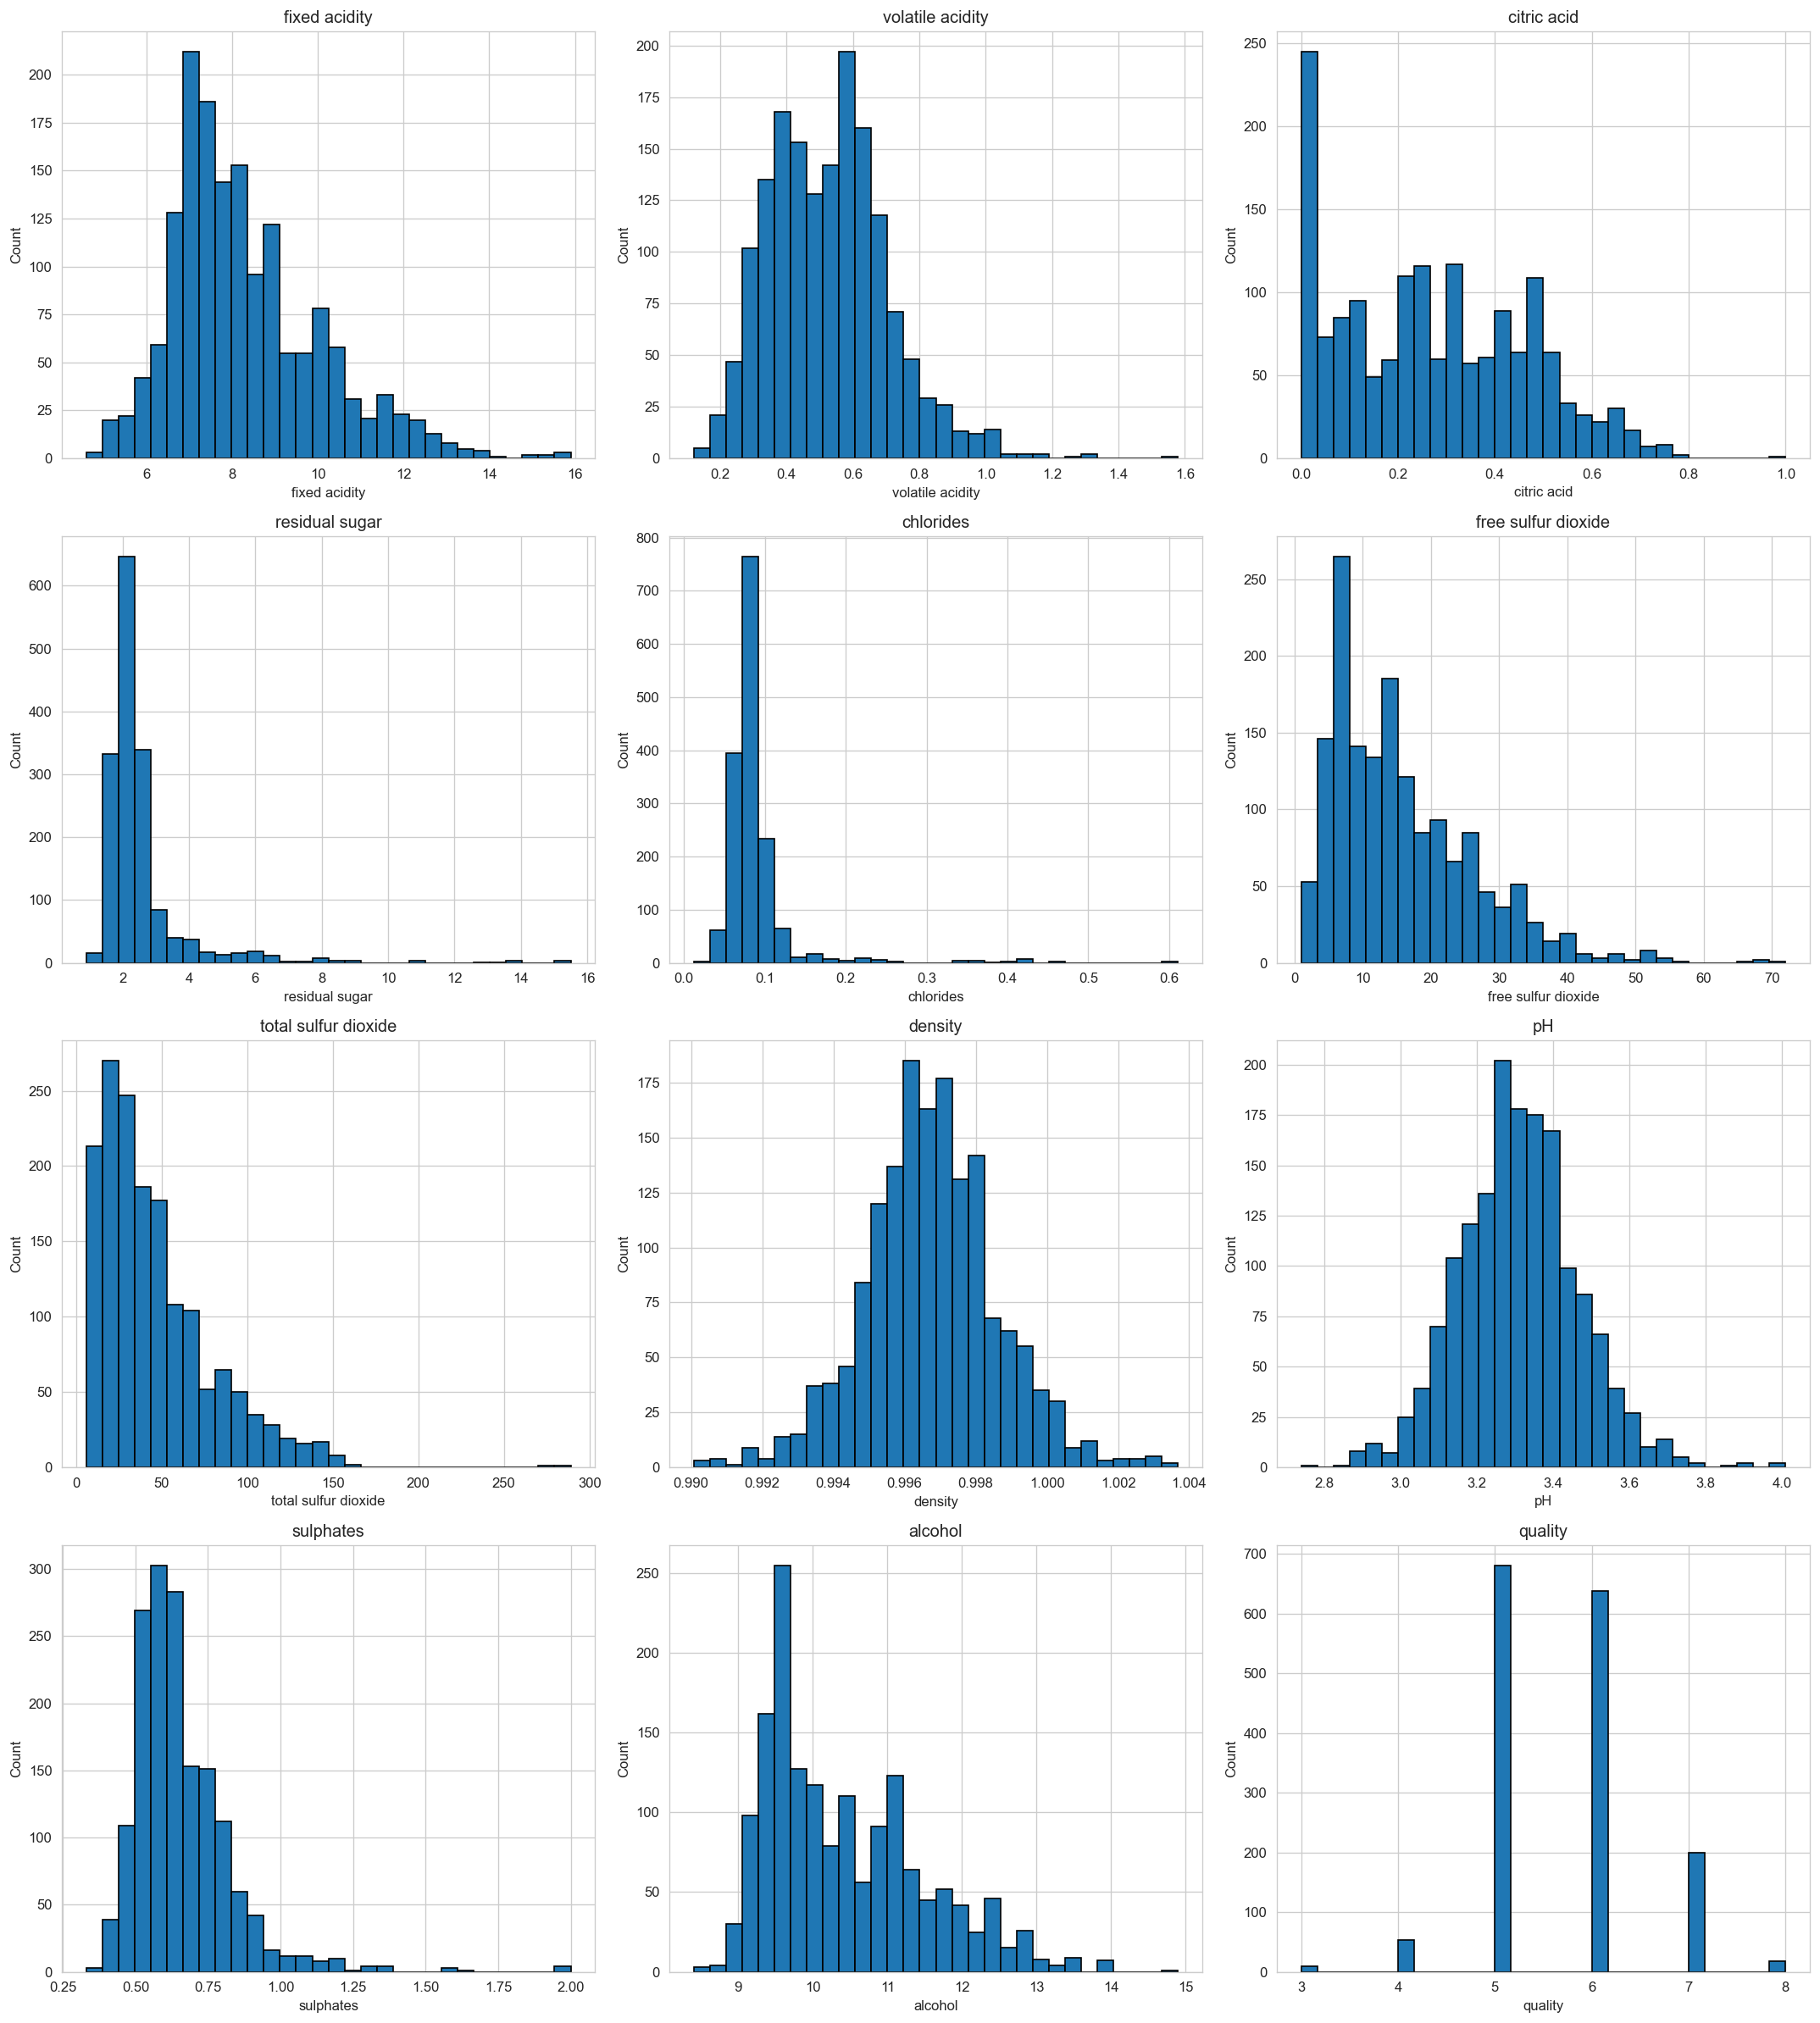

In [52]:
plot_distributions(df)

In [54]:
#Target Profiling

def plot_target_distribution(df, target: str):

    counts = df[target].value_counts().sort_index()

    plt.figure(figsize=(8, 5))
    sns.barplot(x=counts.index, y=counts.values)

    plt.title(f"{target} Distribution")
    plt.xlabel(target)
    plt.ylabel("Count")

    plt.show()

    return counts

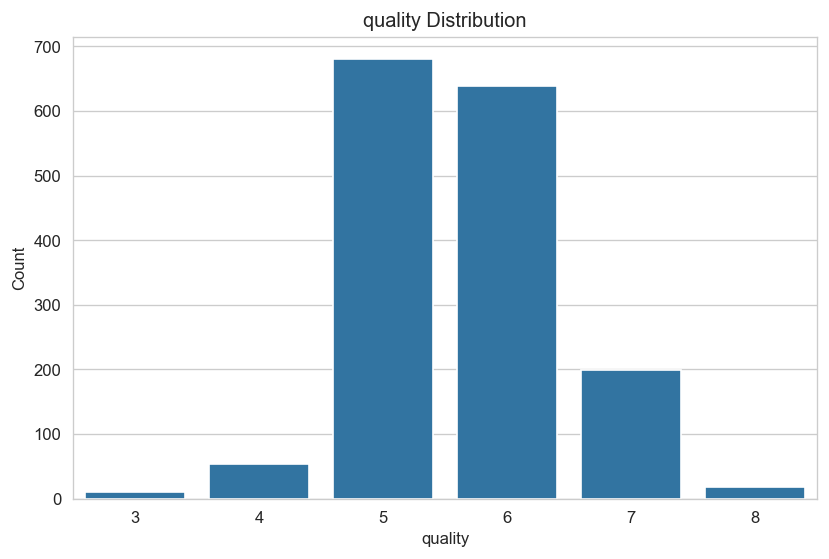

quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64

In [55]:
target_counts = plot_target_distribution(df, "quality")
target_counts

In [56]:
# Correlation Analysis

#Correlation Computation

def compute_correlation (df:pd.DataFrame):
    corr = df.corr(method="pearson")
    return corr

#Heatmap
def plot_correlation_heatmap(corr:pd.DataFrame):
    plt.Figure(figsize=(12,10))

    sns.heatmap(
        corr,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        square=True
    )

    plt.title("Correlation Heatmap")
    plt.show()

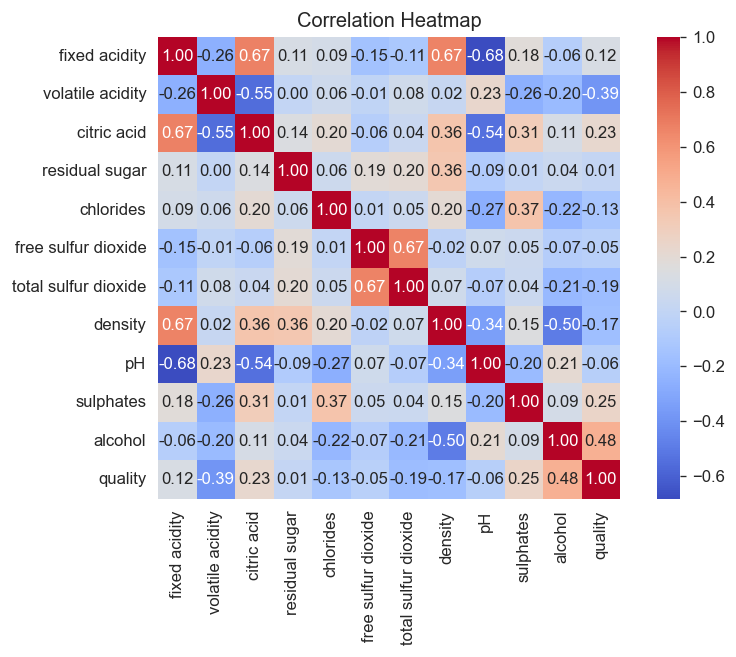

In [61]:
corr = compute_correlation(df)
plot_correlation_heatmap(corr)

In [62]:
# Target Correlations
corr["quality"].sort_values(ascending=False)

#Alcohol is the strongest predictor
#Acidity harms quality


quality                 1.000000
alcohol                 0.476166
sulphates               0.251397
citric acid             0.226373
fixed acidity           0.124052
residual sugar          0.013732
free sulfur dioxide    -0.050656
pH                     -0.057731
chlorides              -0.128907
density                -0.174919
total sulfur dioxide   -0.185100
volatile acidity       -0.390558
Name: quality, dtype: float64

In [63]:
# Feature vs target analysis

#Scatter plot

def plot_feature_vs_target(df, features, target):

    for col in features:

        plt.figure(figsize=(6, 4))

        sns.scatterplot(
            x=df[col],
            y=df[target],
            alpha=0.5
        )

        plt.title(f"{col} vs {target}")
        plt.show()


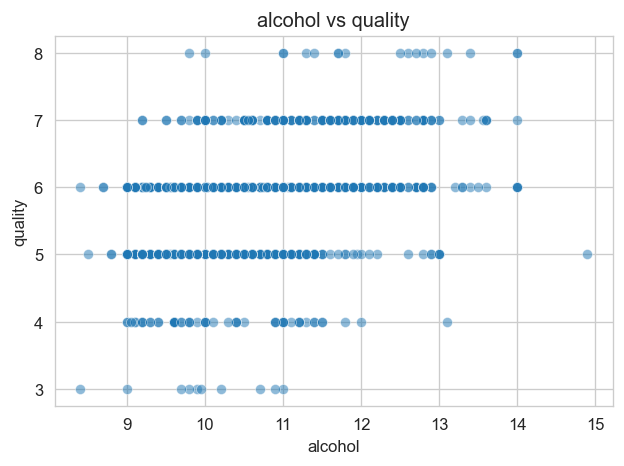

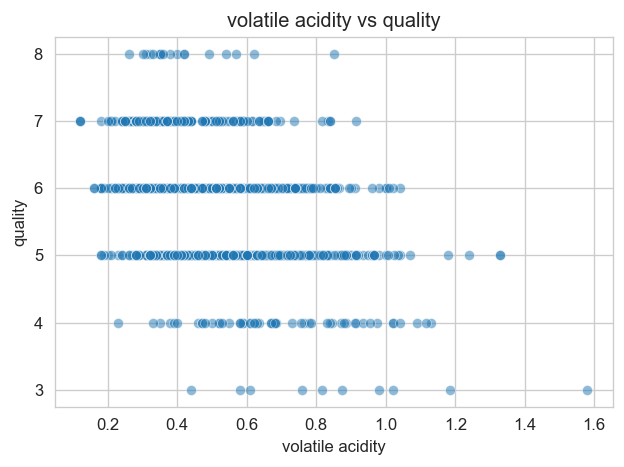

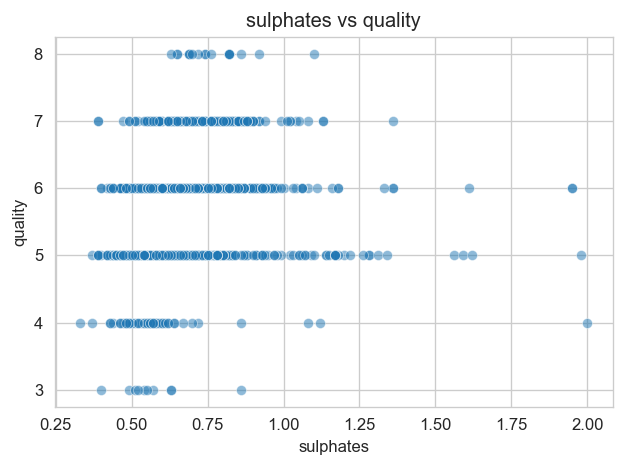

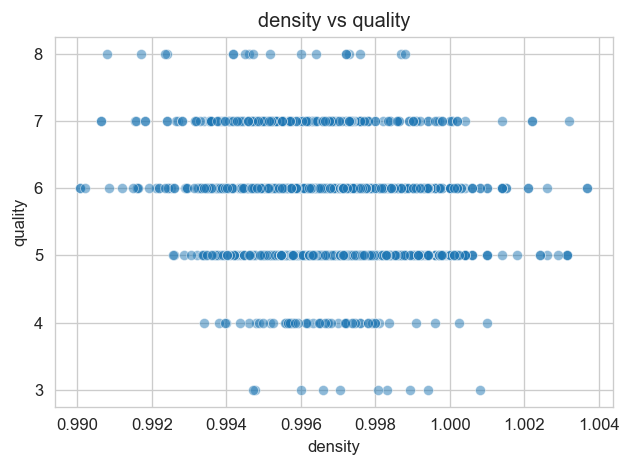

In [64]:
important_features = [
    "alcohol",
    "volatile acidity",
    "sulphates",
    "density"
]

plot_feature_vs_target(df, important_features, "quality")


In [65]:
# Categorical Perspective - we look at feature distribution per class

#Box plot

def plot_feature_by_target(df, feature, target):

    plt.figure(figsize=(8, 5))

    sns.boxplot(
        x=target,
        y=feature,
        data=df
    )

    plt.title(f"{feature} by {target}")
    plt.show()

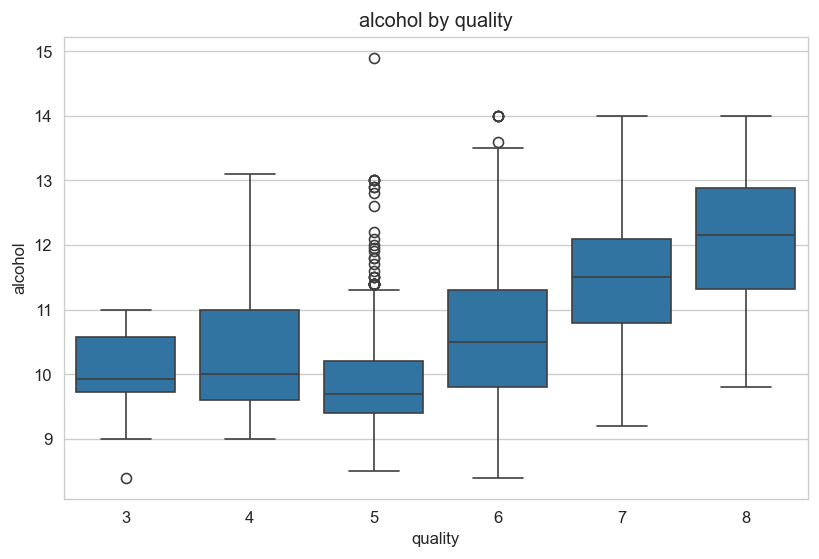

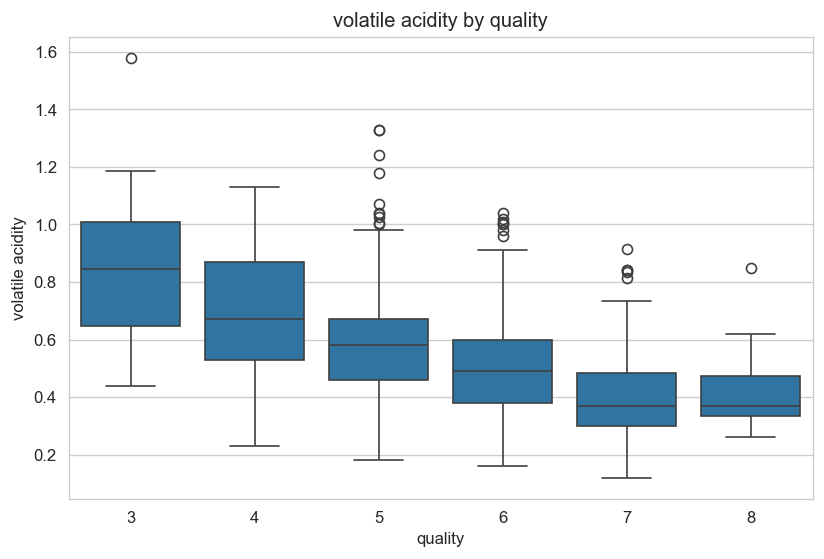

In [66]:
plot_feature_by_target(df, "alcohol", "quality")
plot_feature_by_target(df, "volatile acidity", "quality")

# Median alcohol rises with quality
# Acidity falls qith quality

In [67]:
#Multivarate analysis - detect interactions

def plot_pairwise(df, cols):

    sns.pairplot(
        df[cols],
        diag_kind="kde",
        corner=True
    )

    plt.show()

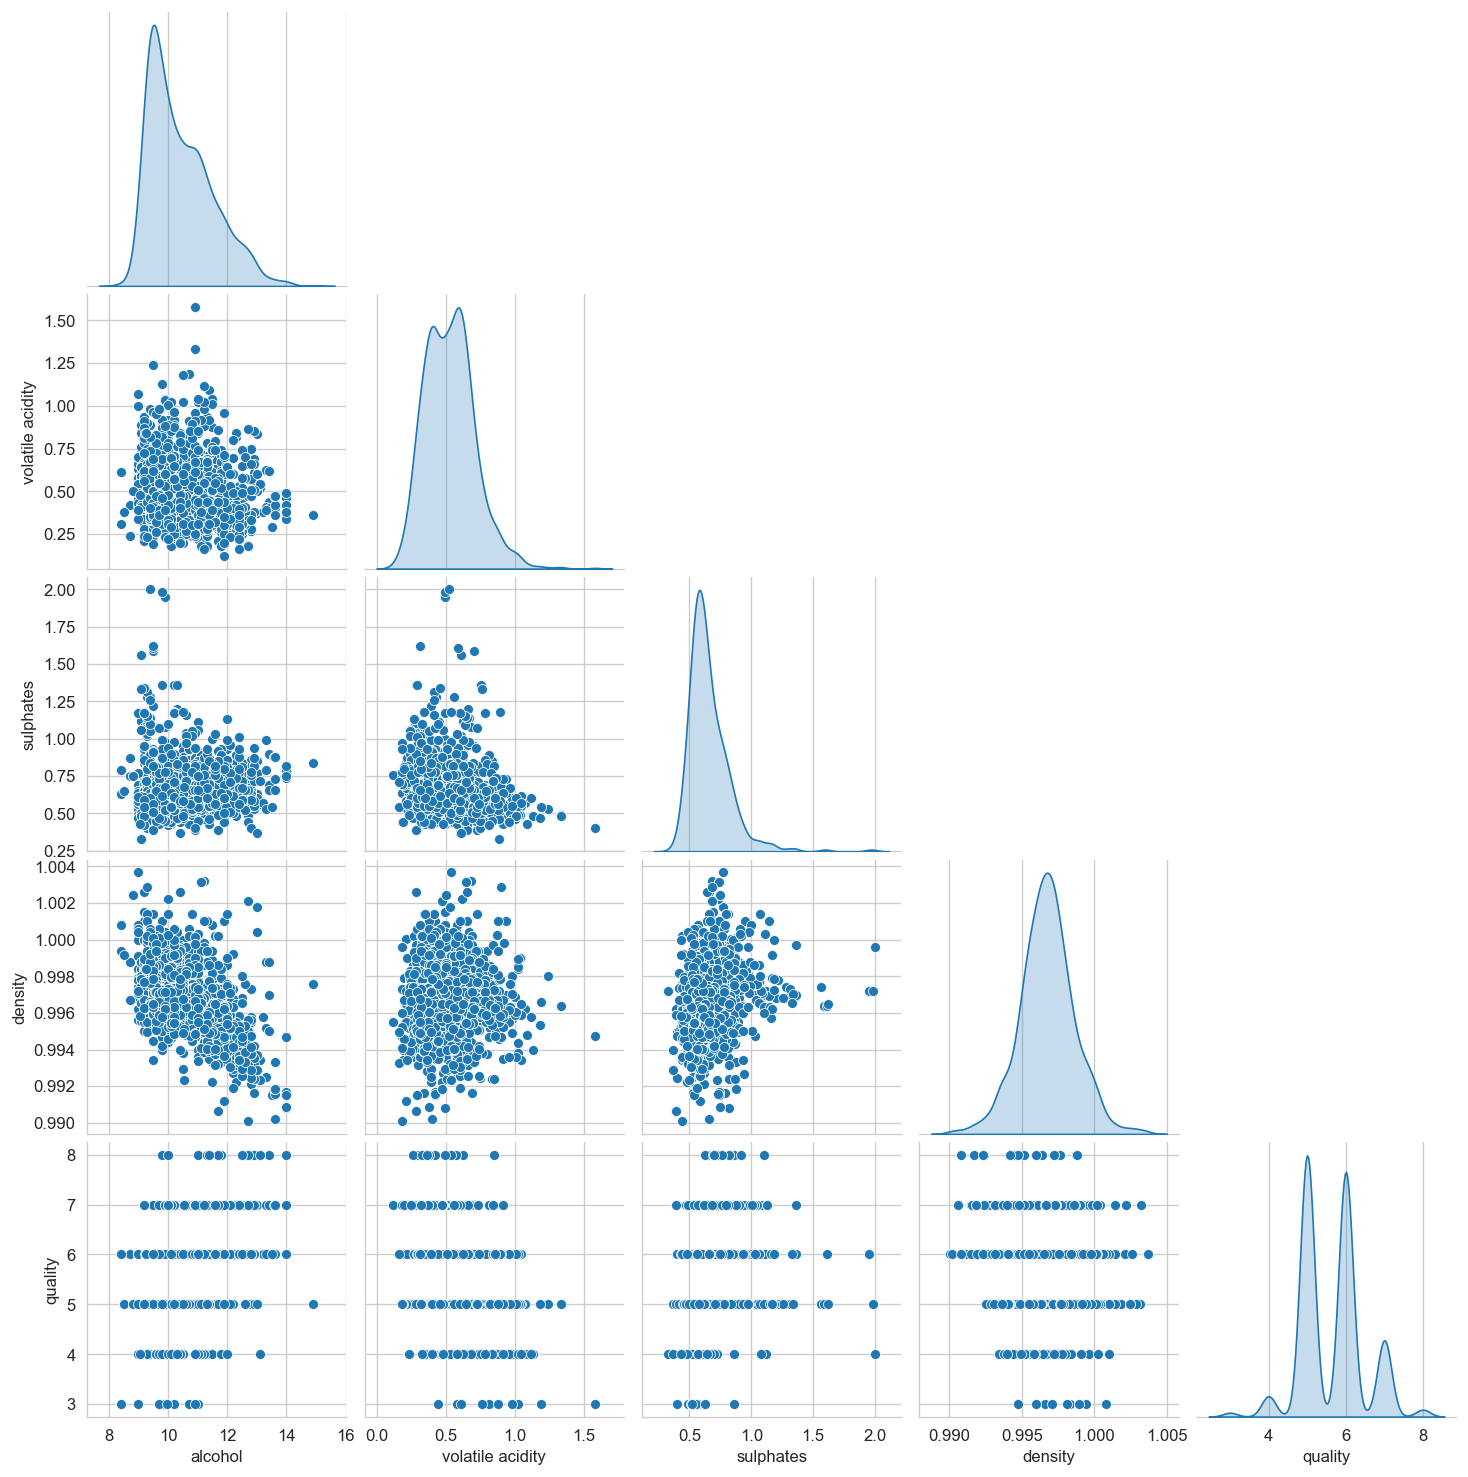

In [68]:
pair_cols = [
    "alcohol",
    "volatile acidity",
    "sulphates",
    "density",
    "quality"
]

plot_pairwise(df, pair_cols)


In [69]:
#Outlier Profiling

def plot_boxplots(df, cols):

    for col in cols:

        plt.figure(figsize=(6, 3))

        sns.boxplot(x=df[col])

        plt.title(col)
        plt.show()


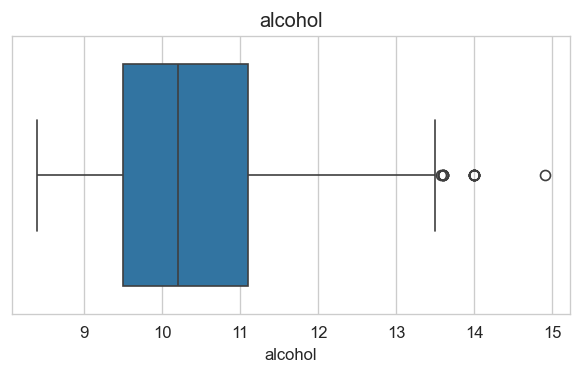

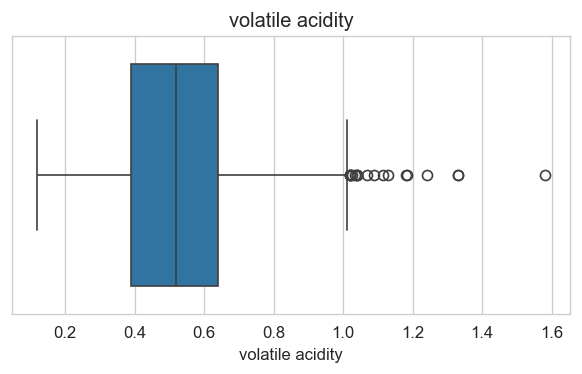

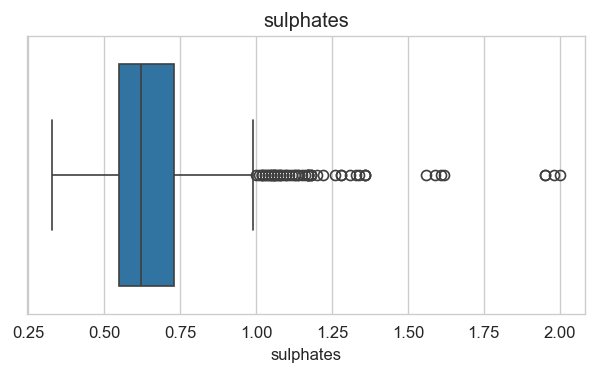

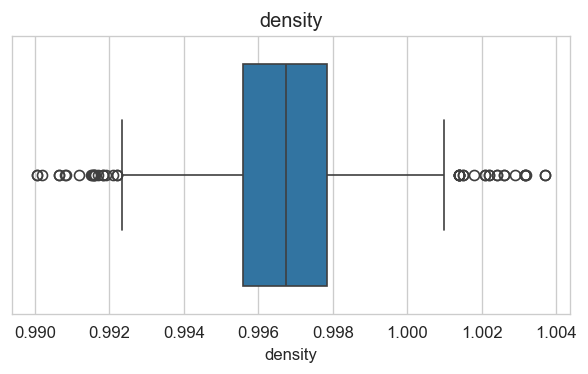

In [70]:
plot_boxplots(df, important_features)


__Data Behavior Summary__

1. Target

    - Strongly concentrated at quality 5–6
    - Imbalanced distribution

2. Key Predictors

    - Alcohol (r = 0.48)
    - Volatile acidity (r = −0.39)
    - Sulphates (r = 0.25)

3. Distributions

    - Residual sugar, SO2 heavily skewed
    - Several long-tailed variables

4. Relationships

    - Mostly monotonic
    - No strong clustering
    - Limited nonlinear interactions

5. Risks

    - Class imbalance
    - Outliers in chemical features
    - SO2 multicollinearity